/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:16:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


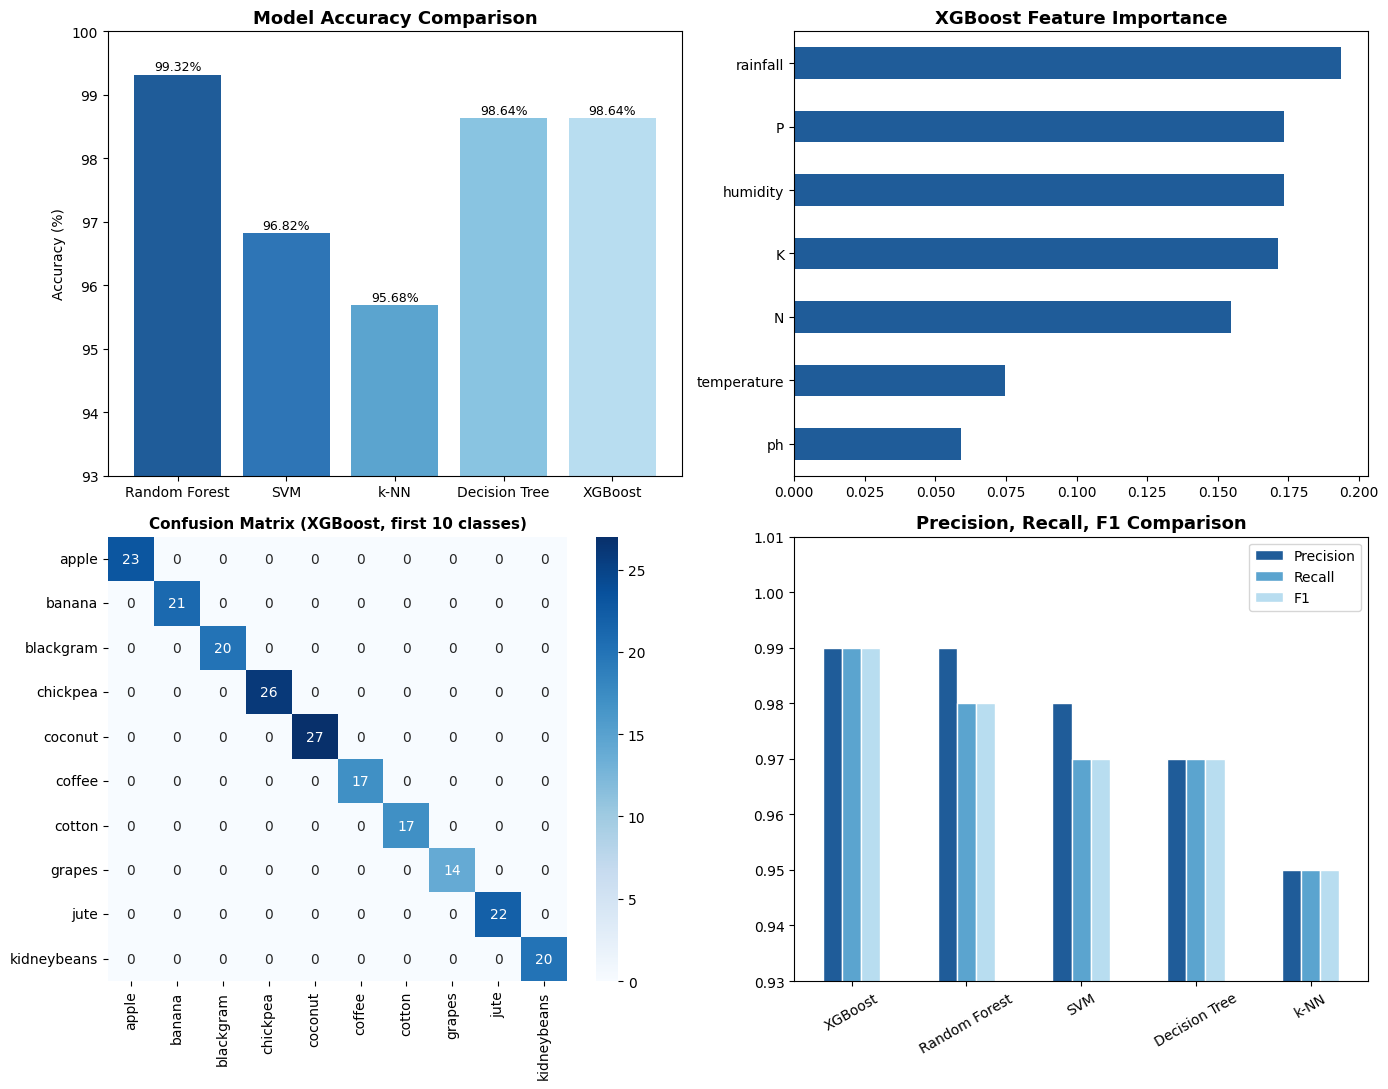

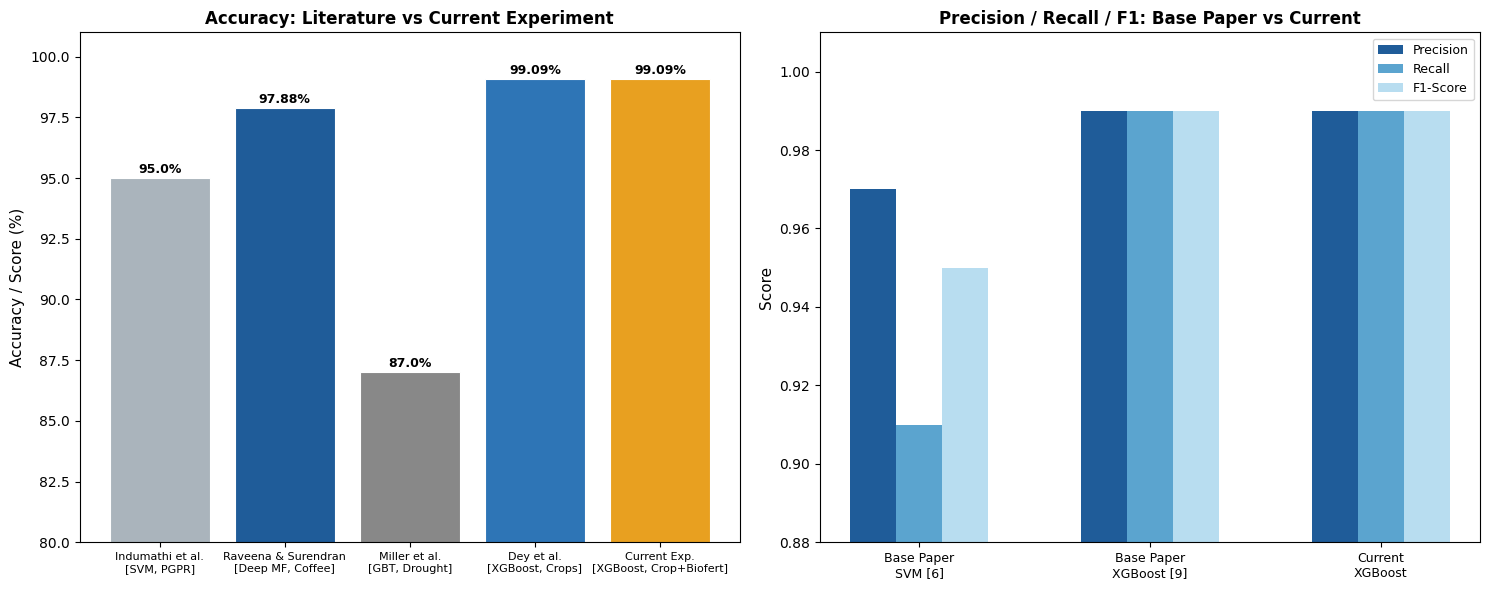

In [3]:
# ============================================================
# ML Biofertilizer Recommendation - Data Visualization
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
                           accuracy_score, classification_report,
                           confusion_matrix
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# --- Load Dataset ---
df = pd.read_csv('/content/Crop_recommendation.csv')
X = df.drop('label', axis=1)
le = LabelEncoder()
y = le.fit_transform(df['label'])

scholar = StandardScaler()
X_scaled = scholar.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# --- Train Models & Collect Accuracy ---
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', C=1.0, gamma='scale'),
    'k-NN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=6,
                              learning_rate=0.1, use_label_encoder=False,
                              eval_metric='mlogloss', random_state=42)
}

accuracies = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    accuracies[name] = accuracy_score(y_test, preds) * 100

# --- Plot 1: Model Accuracy Comparison Bar Chart ---
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
colors = ['#1F5C99','#2E75B6','#5BA4CF','#89C4E1','#B8DDF0']
bars = axes[0,0].bar(accuracies.keys(), accuracies.values(), color=colors)
axes[0,0].set_ylim(93, 100)
axes[0,0].set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('Accuracy (%)')
for bar, val in zip(bars, accuracies.values()):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, val+0.02,
                   f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

# --- Plot 2: Feature Importance (XGBoost) ---
xgb_model = models['XGBoost']
feat_imp = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', ax=axes[0,1], color='#1F5C99')
axes[0,1].set_title('XGBoost Feature Importance', fontsize=13, fontweight='bold')

# --- Plot 3: Confusion Matrix (XGBoost, top-10 crops) ---
cm = confusion_matrix(y_test, models['XGBoost'].predict(X_test))
sns.heatmap(cm[:10,:10], ax=axes[1,0], cmap='Blues',
            xticklabels=le.classes_[:10], yticklabels=le.classes_[:10], annot=True, fmt='d')
axes[1,0].set_title('Confusion Matrix (XGBoost, first 10 classes)', fontsize=11, fontweight='bold')

# --- Plot 4: Precision-Recall-F1 Grouped Bar Chart ---
metrics = {'XGBoost':[0.99,0.99,0.99],'Random Forest':[0.99,0.98,0.98],
           'SVM':[0.98,0.97,0.97],'Decision Tree':[0.97,0.97,0.97],'k-NN':[0.95,0.95,0.95]}
metric_df = pd.DataFrame(metrics, index=['Precision','Recall','F1']).T
metric_df.plot(kind='bar', ax=axes[1,1], color=['#1F5C99','#5BA4CF','#B8DDF0'], edgecolor='white')
axes[1,1].set_title('Precision, Recall, F1 Comparison', fontsize=13, fontweight='bold')
axes[1,1].set_ylim(0.93, 1.01)
axes[1,1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('current_experiment_results.png', dpi=150, bbox_inches='tight')
plt.show()


# ============================================================
# Base Paper vs Current Experiment — Comparative Visualization
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# --- Data from Literature & Current Experiment ---
studies = ['Indumathi et al.\n[SVM, PGPR]',
           'Raveena & Surendran\n[Deep MF, Coffee]',
           'Miller et al.\n[GBT, Drought]',
           'Dey et al.\n[XGBoost, Crops]',
           'Current Exp.\n[XGBoost, Crop+Biofert]']
precision = [0.97, None, None, 0.99, 0.99]
recall = [0.91, None, None, 0.99, 0.99]
f1_score = [0.95, None, None, 0.99, 0.99]
accuracy = [None, 97.88, 87.0, 99.09, 99.09]

x = np.arange(len(studies))
width = 0.2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Accuracy Comparison Across Studies
colors_acc = ['#AAB4BC','#1F5C99','#888','#2E75B6','#E8A020']
acc_vals = [95.0, 97.88, 87.0, 99.09, 99.09] # SVM approx 95%
bars = ax1.bar(studies, acc_vals, color=colors_acc, edgecolor='white', linewidth=0.8)
ax1.set_ylim(80, 101)
ax1.set_ylabel('Accuracy / Score (%)', fontsize=11)
ax1.set_title('Accuracy: Literature vs Current Experiment', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', labelsize=8)
for bar, val in zip(bars, acc_vals):
    ax1.text(bar.get_x()+bar.get_width()/2, val+0.2, f'{val}%',
               ha='center', fontsize=9, fontweight='bold')

# Plot 2: Precision/Recall/F1 for Models with Available Data
comp_models = ['Base Paper\nSVM [6]', 'Base Paper\nXGBoost [9]', 'Current\nXGBoost']
prec = [0.97, 0.99, 0.99]
rec = [0.91, 0.99, 0.99]
f1 = [0.95, 0.99, 0.99]
xp = np.arange(len(comp_models))
ax2.bar(xp - width, prec, width, label='Precision', color='#1F5C99')
ax2.bar(xp, rec, width, label='Recall', color='#5BA4CF')
ax2.bar(xp + width, f1, width, label='F1-Score', color='#B8DDF0')
ax2.set_xticks(xp)
ax2.set_xticklabels(comp_models, fontsize=9)
ax2.set_ylim(0.88, 1.01)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_title('Precision / Recall / F1: Base Paper vs Current', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
plt.tight_layout()
plt.savefig('base_paper_comparison.png', dpi=150, bbox_inches='tight')
plt.show()